In [89]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [90]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(f'{len(words)} words in dataset')
print(max(len(word) for word in words))
print(words[:8])


32033 words in dataset
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [91]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for i, s in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [92]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(name, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(
        f"{name:<15} | exact: {str(ex):>5} | approximate: {str(app):>5} | maxdiff {maxdiff}"
    )

In [93]:
block_size = 3 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%


In [94]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP
block_size = 3 # the number of characters to take as input to the model

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g) # embedding table

# Layer 1:
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn((n_hidden), generator=g) * 0.1 # using b1 just for fun, it's useless because of the batch norm, it will be subtracted out

# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn((vocab_size), generator=g) * 0.1

# BatchNorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g, all zeros could mask an incorrect
# implementation of the bacward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.numel() for p in parameters))

for p in parameters:
    p.requires_grad = True




4137


In [95]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience

# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]


In [ ]:
# forward pass, "chunked" into smaller steps that are possible to backward one at a time
emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors 
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/batch_size*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff ** 2
bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer 
# Linear layer 2
logits = h @ W2 + b2 # output layer 
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logits_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logits_maxes # subtract max for numerical stability. make sure softmax won't
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact.....
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# pytorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
norm_logits, logits_maxes, logits, h, hpreact, bnraw, bnvar, bndiff, bndiff2, bnvar_inv, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3251, grad_fn=<NegBackward0>)

In [97]:
# Step1 dlogprobs = ???
# 1.1 check logprobs.shape
print(logprobs.shape)
# 1.2 check Yb, is an array of all the correct indices
print(Yb)
# 1.3 check logprobs[range(n), Yb].shape
print(logprobs[range(n), Yb].shape)
# 1.4 check loss.shape
print(loss.shape)
# 1.5 understand of logprobs[range(n), Yb]
print(logprobs[range(n), Yb].shape)
# thinking process:
# loss = -(a + b + c) / 3
# loss = -1/3a -1/3b -1/3c
# dloss/da = -1/n
# think more, since we only pluck out one element for each batch, so other elements are not used, and their gradients are 0
# so the correct implementation should be:
dlogprobs = torch.zeros_like((logprobs)) # create a zero tensor with the same shape as logprobs
dlogprobs[range(n), Yb] = -1.0/n # set the gradient of the correct element to -1/n
 
cmp('dlogprobs', dlogprobs, logprobs)


torch.Size([32, 27])
tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])
torch.Size([32])
torch.Size([])
torch.Size([32])
dlogprobs       | exact:  True | approximate:  True | maxdiff 0.0


In [98]:
# Step 2 dprobs = ???
# 2.1 note that dlogx = 1/x # can look up from website
dprobs = (1.0 / probs) * dlogprobs # apply chain rule. intuition: if probs is close to 1, which means the prediction is very correct, then dlogprobs just pass through. 
# but if probs are incorrectly assigned, then 1.0 / probs will boost this, 
cmp('dprobs', dprobs, probs)

# Step 3 dcounts_sum_inv = ???
# 3.1 scrutinize the shapes
print(counts.shape, counts_sum_inv.shape)
# so it means broadcast is done here; refer to below example 
# c = a * b, but with eensors:
# a[3x3] * b[3,1] ----- >
#a11*b1 a12*b1 a13*b1
#a21*b2 a22*b2 a23*b2
#a31*b3 a32*b3 a33*b3
# so it means broadcast is done here; refer to below example 
# c = a * b, but with eensors:
# a[3x3] * b[1,3] ----- >
#a11*b1 a12*b1 a13*b1
#a21*b2 a22*b2 a23*b2
#a31*b3 a32*b3 a33*b3

# so counts * counts_sum_inv appears like one single operation, but it's actually two operations applied sequentially:
# so when doing backprob, we need to 1) backprob through multiplication, and 2) backprob through counts_sum_inv
# think more if we have c = a * b, then what's dc/da? dc/da = b  -> but b is replicative b 
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # sum over the rows because b11 is replicated multiple times
cmp('dcounts_sum_inv', dcounts_sum_inv, counts_sum_inv)

# Step 4-1 dcounts = ???
dcounts = counts_sum_inv * dprobs # counts_sum_inv.shape = [32,1], and dprobs.shape = [32,10] so it should be broadcasted.
# cmp('dcounts', dcounts, counts) # should not check dcounts this earlier becuase counts_sum_inv depends on counts

# Step 5 dcounts_sum = ???
dcounts_sum = -counts_sum**-2 * dcounts_sum_inv # don't forget the chain rule!!!
cmp('dcounts_sum', dcounts_sum, counts_sum)


# step 4-2 dcounts = ???
print(counts.shape, counts_sum.shape)
# a11 a12 a13 ----> b1 (=a11+a12+a13)
# a21 a22 a23 ----> b2 (=a21+a22+a23)
# a31 a32 a33 ----> b3 (=a31+a32+a33)
dcounts += torch.ones_like(counts) * dcounts_sum # replicate dcounts_sum across the rows
cmp('dcounts', dcounts, counts)
print(dcounts.shape)




dprobs          | exact:  True | approximate:  True | maxdiff 0.0
torch.Size([32, 27]) torch.Size([32, 1])
dcounts_sum_inv | exact:  True | approximate:  True | maxdiff 0.0
dcounts_sum     | exact:  True | approximate:  True | maxdiff 0.0
torch.Size([32, 27]) torch.Size([32, 1])
dcounts         | exact:  True | approximate:  True | maxdiff 0.0
torch.Size([32, 27])


In [99]:
# step 5 dnorm_logits = ???
dnorm_logits = counts * dcounts 
cmp('dnorm_logits', dnorm_logits, norm_logits)

dnorm_logits    | exact:  True | approximate:  True | maxdiff 0.0


In [100]:
# step 6 dlogits = ???
# becareful again, shape here is not same
# an implicit broadcast is done here
print(norm_logits.shape, logits.shape, logits_maxes.shape)
# c11 c12 c13 = a11 a12 a13   b1
# c21 c22 c23 = a21 a22 a23 - b2
# c31 c32 c33 = a31 a32 a33   b3
# so e.g, c32 = a32 - b3
dlogits = dnorm_logits.clone() # not the final dlogits
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
cmp('dlogit_maxes', dlogit_maxes, logits_maxes)

# to be noted here, dlogit_maxes is expected to be 0 since dlogit_maxes won't influence the final result
# because each row of dlogit_maxes is the same, and will be subtracted out in the next step
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
cmp('dlogits', dlogits, logits)

torch.Size([32, 27]) torch.Size([32, 27]) torch.Size([32, 1])
dlogit_maxes    | exact:  True | approximate:  True | maxdiff 0.0
dlogits         | exact:  True | approximate:  True | maxdiff 0.0


In [101]:
# also has broadcast here +
dlogits.shape, h.shape, W2.shape, b2.shape

(torch.Size([32, 27]),
 torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]))

In [102]:
dh = dlogits @ W2.T # make sure the shape is correct when doing matrix multiplication
cmp('dh', dh, h)

dW2 = h.T @ dlogits
cmp('dW2', dW2, W2)

db2 = dlogits.sum(0) # dimension is 0 because we need to eliminate the batch dimension
cmp('db2', db2, b2)



dh              | exact:  True | approximate:  True | maxdiff 0.0
dW2             | exact:  True | approximate:  True | maxdiff 0.0
db2             | exact:  True | approximate:  True | maxdiff 0.0


In [103]:
dhpreact = dh *(1.0 - h**2) # apply chain rule
cmp('dhpreact', dhpreact, hpreact)


dhpreact        | exact:  True | approximate:  True | maxdiff 0.0


In [104]:
# watch out the broadcast here in hpreact = bngain * bnraw + bnbias
hpreact.shape, bngain.shape, bnraw.shape, bnbias.shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]))

In [105]:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # sum over the direction that it's get replicated
cmp('dbngain', dbngain, bngain)

dbnraw = bngain * dhpreact
cmp('dbnraw', dbnraw, bnraw)

dbnbias = dhpreact.sum(0, keepdim=True)
cmp('dbnbias', dbnbias, bnbias)

dbngain         | exact:  True | approximate:  True | maxdiff 0.0
dbnraw          | exact:  True | approximate:  True | maxdiff 0.0
dbnbias         | exact:  True | approximate:  True | maxdiff 0.0


In [106]:
bnraw.shape, bndiff.shape, bnvar.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [117]:
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0)
cmp('dbnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar_inv      | exact:  True | approximate:  True | maxdiff 0.0


In [108]:
dbnvar = (-0.5 * (bnvar + 1e-5) **-1.5) * dbnvar_inv
cmp('dbnvar', dbnvar, bnvar)



dbnvar          | exact:  True | approximate:  True | maxdiff 0.0


In [109]:
bnvar.shape, bndiff2.shape
# a11 a12
# a21 a22
# -->
# b1 b2, where
# b1 = 1/(n-1) * (a11 + a21)
# b2 = 1/(n-1) * (a12 + a22)

(torch.Size([1, 64]), torch.Size([32, 64]))

In [110]:
dbndiff2 = (1.0/(n-1.0)) * torch.ones_like(bndiff2) * dbnvar
cmp('dbndiff2', dbndiff2, bndiff2)

dbndiff += 2 * bndiff * dbndiff2
cmp('dbndiff', dbndiff, bndiff)



dbndiff2        | exact:  True | approximate:  True | maxdiff 0.0
dbndiff         | exact:  True | approximate:  True | maxdiff 0.0


In [111]:
bndiff.shape, hprebn.shape, bnmeani.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [116]:
dhprebn = dbndiff.clone() # for safety
dbnmeani = (-dbndiff).sum(0)
cmp('dbnmeani', dbnmeani, bnmeani)

dhprebn += torch.ones_like(hprebn) * dbnmeani * (1.0/batch_size)
cmp('dhprebn', dhprebn, hprebn)



dbnmeani        | exact:  True | approximate:  True | maxdiff 0.0
dhprebn         | exact:  True | approximate:  True | maxdiff 0.0


In [113]:
bnmeani.shape, hprebn.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [114]:
hprebn.shape, embcat.shape, W1.shape, b1.shape

(torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([30, 64]),
 torch.Size([64]))

In [115]:
dW1 = embcat.T @ dhprebn
cmp('dW1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('db1', db1, b1)

dembcat = dhprebn @ W1.T
cmp('dembcat', dembcat, embcat)





dW1             | exact:  True | approximate:  True | maxdiff 0.0
db1             | exact:  True | approximate:  True | maxdiff 0.0
dembcat         | exact:  True | approximate:  True | maxdiff 0.0


In [118]:
embcat.shape, emb.shape

(torch.Size([32, 30]), torch.Size([32, 3, 10]))

In [ ]:
demb = dembcat.view(emb.shape) # re-represent the view to the original shape
cmp('demb', demb, emb)

demb            | exact:  True | approximate:  True | maxdiff 0.0


In [122]:
emb.shape, C.shape, Xb.shape

(torch.Size([32, 3, 10]), torch.Size([27, 10]), torch.Size([32, 3]))

In [ ]:
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
cmp('dC', dC, C)

dC              | exact:  True | approximate:  True | maxdiff 0.0


In [124]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# before
# cross entropy loss (same as F.cross_entropy(logits, Yb))
# logits_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logits_maxes # subtract max for numerical stability. make sure softmax won't overflow
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdim=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact.....
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss - loss_fast).item())

3.3251242637634277 diff: 0.0


In [125]:
# backward pass
dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1.0
dlogits /= n

cmp('dlogits', dlogits, logits)

dlogits         | exact: False | approximate:  True | maxdiff 5.587935447692871e-09


In [127]:
F.softmax(logits, dim=1)[0]

tensor([0.0795, 0.0844, 0.0201, 0.0513, 0.0181, 0.0871, 0.0241, 0.0376, 0.0164,
        0.0293, 0.0338, 0.0365, 0.0384, 0.0275, 0.0332, 0.0136, 0.0098, 0.0174,
        0.0148, 0.0546, 0.0485, 0.0235, 0.0259, 0.0644, 0.0606, 0.0261, 0.0235],
       grad_fn=<SelectBackward0>)

In [128]:
dlogits[0] * n

tensor([ 0.0795,  0.0844,  0.0201,  0.0513,  0.0181,  0.0871,  0.0241,  0.0376,
        -0.9836,  0.0293,  0.0338,  0.0365,  0.0384,  0.0275,  0.0332,  0.0136,
         0.0098,  0.0174,  0.0148,  0.0546,  0.0485,  0.0235,  0.0259,  0.0644,
         0.0606,  0.0261,  0.0235], grad_fn=<MulBackward0>)

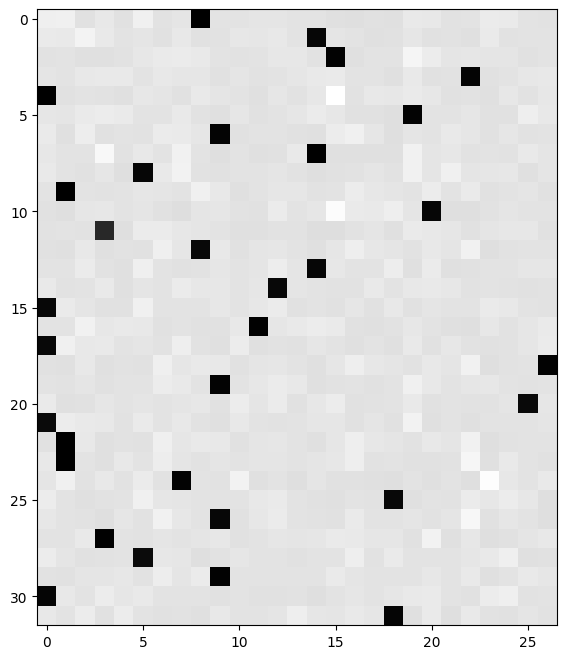

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray')

# think of the gradients here at each cell as like a force, pulling down the probabilities of the incorrect indices and pulling up the probabilities of the correct index

In [130]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass
# before
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff ** 2
# bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact - hpreact_fast).abs().max().item())

max diff: 4.76837158203125e-07


In [ ]:
# calculate dhprebn given dhpreact (i.e. backprop through batchnorm)
# you wil also need to use some of the variables from the forward pass up
dhprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n / (n-1) * bnraw * (dhpreact * bnraw).sum(0))
cmp('dhprebn', dhprebn, hprebn)




dhprebn         | exact: False | approximate:  True | maxdiff 9.313225746154785e-10
